<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# YOLO26: Detecção de Objetos End-to-End

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

<a href="https://colab.research.google.com/github/carlosfab/blog-sigmoidal/blob/main/YOLO26-Deteccao-de-Objetos/yolo26_deteccao_objetos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Google Colab"></a>

O **YOLO26** reorganiza a detecção de objetos para produzir previsões finais diretamente pela rede, sem aplicar supressão de não máximos (NMS) no caminho padrão. Neste notebook, você usará o modelo compacto `yolo26n.pt` para localizar objetos na imagem canônica `bus.jpg`.

O percurso será direto: instalar a biblioteca, obter a imagem oficial, executar a inferência, visualizar o resultado e examinar cada detecção.

## 1. Como preparar o ambiente?

As três dependências centrais são fixadas para tornar o exemplo reproduzível. O OpenCV permanece na série 4.11, compatível com NumPy 1.26 e sem a exigência de NumPy 2 introduzida pelo OpenCV 5.x.

In [1]:
%%capture
%pip install -q "numpy==1.26.4" "opencv-python==4.11.0.86" "ultralytics==8.4.118"

Essa combinação inclui a API de inferência e impede que o resolvedor instale simultaneamente `numpy<2` e `opencv-python` 5.x, cujos requisitos são incompatíveis.

## 2. Como obter a imagem oficial?

O exemplo utiliza a fotografia `bus.jpg` apresentada no [quickstart do YOLO26](https://github.com/ultralytics/yolo26) e na [documentação oficial](https://docs.ultralytics.com/models/yolo26/). A cópia hospedada neste repositório é idêntica ao arquivo publicado pela Ultralytics em [`ultralytics.com/images/bus.jpg`](https://ultralytics.com/images/bus.jpg). O código também confere seu hash SHA-256 antes de prosseguir.

**Crédito da imagem:** Ultralytics.

Imagem validada: bus.jpg (c02019c4979c…)


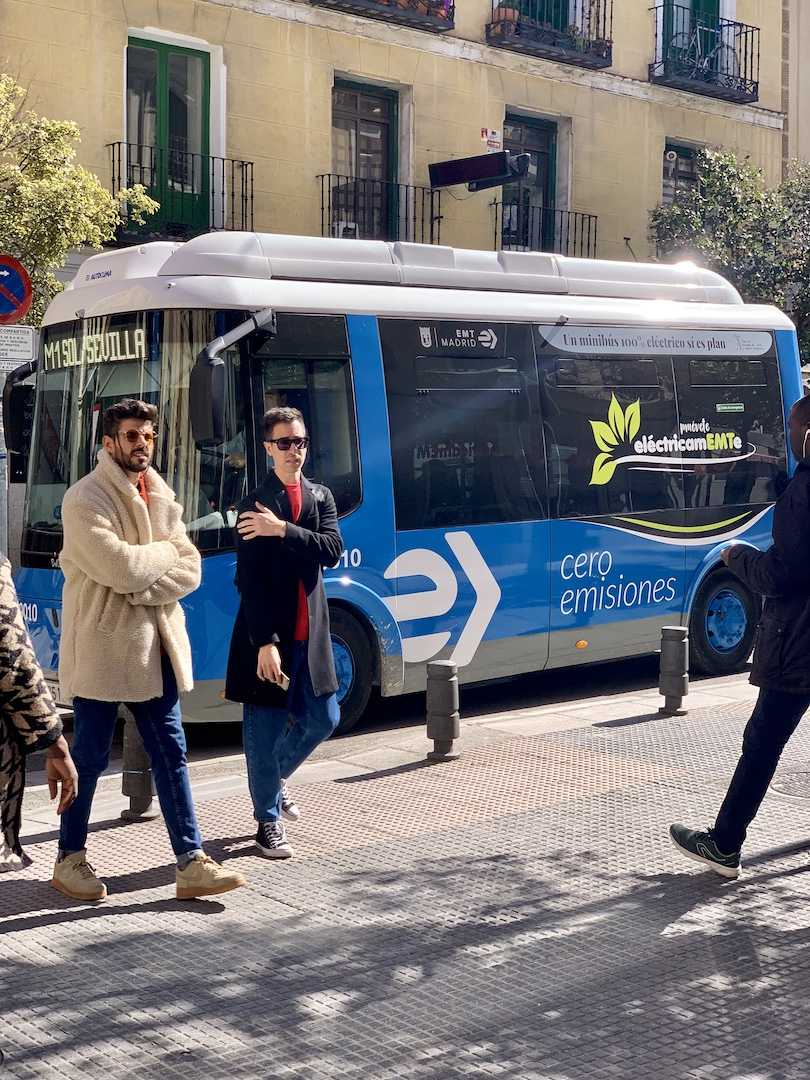

In [2]:
from hashlib import sha256
from pathlib import Path
from urllib.request import urlretrieve

from IPython.display import Image as NotebookImage, display

URL_IMAGEM = (
    "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/"
    "main/YOLO26-Deteccao-de-Objetos/bus.jpg"
)
HASH_OFICIAL = "c02019c4979c191eb739ddd944445ef408dad5679acab6fd520ef9d434bfbc63"
imagem_entrada = Path("bus.jpg")

urlretrieve(URL_IMAGEM, imagem_entrada)
hash_imagem = sha256(imagem_entrada.read_bytes()).hexdigest()
assert hash_imagem == HASH_OFICIAL, "A imagem baixada não corresponde ao arquivo oficial."

print(f"Imagem validada: {imagem_entrada} ({hash_imagem[:12]}…)")
display(
    NotebookImage(
        filename=str(imagem_entrada),
        width=800,
        alt="Cena urbana com um ônibus e pedestres, sem caixas de detecção.",
    )
)

A cena contém um ônibus e pessoas em diferentes posições, escalas e níveis de oclusão. Ela permite observar, em uma única imagem, como o detector combina **classe**, **confiança** e **coordenadas da caixa**.

## 3. Como carregar o YOLO26n?

O arquivo `yolo26n.pt` representa a versão *nano*, a menor da família. Os pesos são baixados automaticamente na primeira execução. Em seguida, verificamos se a cabeça de detecção conserva o comportamento **end-to-end** padrão.

In [3]:
from IPython.utils.capture import capture_output

import cv2
import numpy as np

# Oculta apenas mensagens operacionais de configuração e download.
with capture_output():
    import ultralytics
    from ultralytics import YOLO

    modelo = YOLO("yolo26n.pt")

cabeca_deteccao = modelo.model.model[-1]
assert cabeca_deteccao.end2end is True, "O modelo não está no modo end-to-end padrão."

print(f"Ultralytics: {ultralytics.__version__}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"Inferência end-to-end: {cabeca_deteccao.end2end}")

Ultralytics: 8.4.118
NumPy: 1.26.4
OpenCV: 4.11.0
Inferência end-to-end: True


O valor `True` confirma o caminho nativo do YOLO26: a saída final usa a cabeça *one-to-one*, sem ativar manualmente o fluxo convencional com NMS.

## 4. O que o modelo detecta?

A chamada abaixo processa a imagem com os parâmetros padrão da biblioteca. Depois, o resultado anotado é salvo como `resultado_yolo26.jpg` e exibido no próprio notebook.

Artefato salvo em: resultado_yolo26.jpg


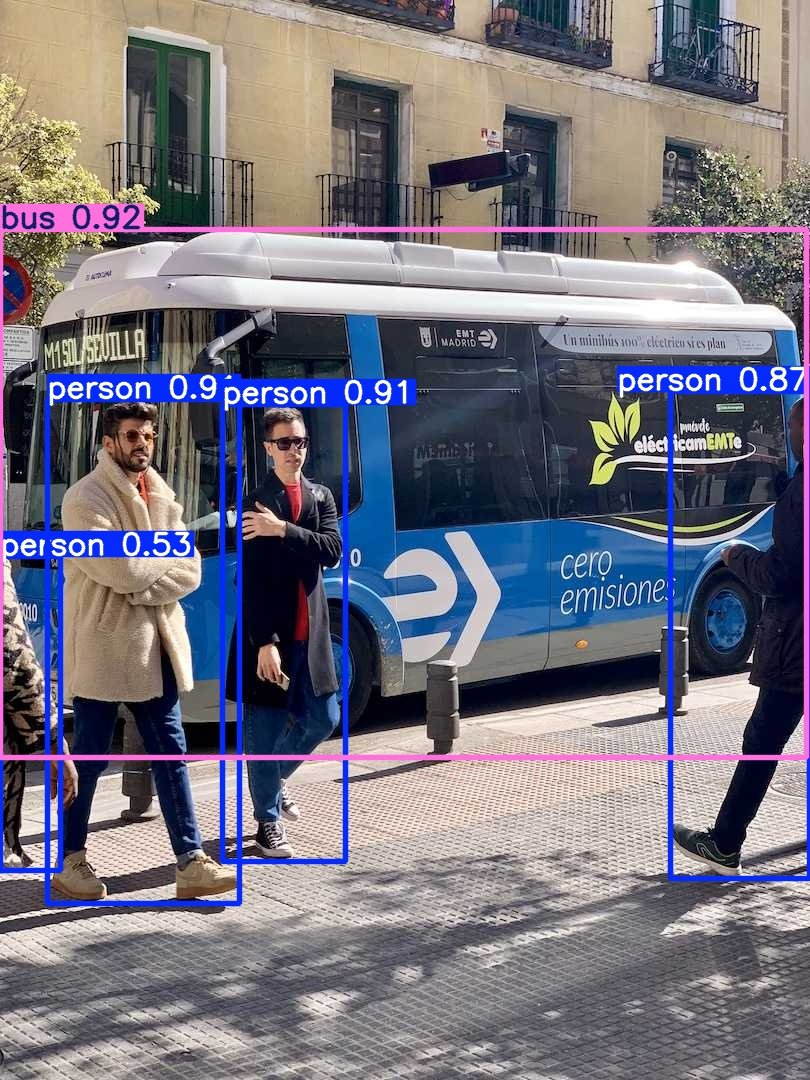

In [4]:
from PIL import Image as PILImage

resultado = modelo.predict(source=str(imagem_entrada), verbose=False)[0]
imagem_saida = Path("resultado_yolo26.jpg")
resultado.save(filename=str(imagem_saida), font_size=18, line_width=3)

with PILImage.open(imagem_saida) as arquivo_imagem:
    imagem_otimizada = arquivo_imagem.convert("RGB")
imagem_otimizada.save(imagem_saida, quality=85, optimize=True, progressive=True)

print(f"Artefato salvo em: {imagem_saida}")
display(
    NotebookImage(
        filename=str(imagem_saida),
        width=800,
        alt="Resultado do YOLO26 com caixas para um ônibus e quatro pessoas.",
    )
)

As caixas mostram as previsões que ultrapassaram o limiar de confiança padrão. Nenhuma anotação foi desenhada manualmente: a imagem final deriva diretamente do objeto retornado pela inferência.

## 5. Como ler as detecções?

Cada linha apresenta a classe prevista, sua confiança e as coordenadas `(x1, y1, x2, y2)` da caixa delimitadora em pixels. A origem da imagem fica no canto superior esquerdo.

In [5]:
from collections import Counter

deteccoes = []
for indice, caixa in enumerate(resultado.boxes, start=1):
    classe_id = int(caixa.cls.item())
    confianca = float(caixa.conf.item())
    x1, y1, x2, y2 = caixa.xyxy[0].tolist()
    deteccoes.append(
        {
            "id": indice,
            "classe": resultado.names[classe_id],
            "confianca": confianca,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
        }
    )

print(f"{'ID':>2}  {'Classe':<8} {'Confiança':>10}  {'x1':>7} {'y1':>7} {'x2':>7} {'y2':>7}")
print("-" * 61)
for deteccao in deteccoes:
    print(
        f"{deteccao['id']:>2}  {deteccao['classe']:<8} "
        f"{deteccao['confianca']:>10.1%}  "
        f"{deteccao['x1']:>7.1f} {deteccao['y1']:>7.1f} "
        f"{deteccao['x2']:>7.1f} {deteccao['y2']:>7.1f}"
    )

contagem_classes = Counter(item["classe"] for item in deteccoes)
assert len(deteccoes) == 5, "A execução não retornou as cinco detecções esperadas."
assert contagem_classes == Counter({"person": 4, "bus": 1})
print(f"\nResumo validado: {len(deteccoes)} detecções — 1 ônibus e 4 pessoas.")

ID  Classe    Confiança       x1      y1      x2      y2
-------------------------------------------------------------
 1  bus           92.4%      0.0   229.4   806.1   757.1
 2  person        91.3%    222.5   404.9   345.4   861.6
 3  person        90.5%     47.7   399.3   239.3   903.0
 4  person        87.0%    670.7   391.5   809.8   879.0
 5  person        53.5%      0.1   556.7    60.0   870.1

Resumo validado: 5 detecções — 1 ônibus e 4 pessoas.


O resultado validado contém **cinco detecções: um ônibus e quatro pessoas**. As confianças expressam o grau de evidência atribuído pelo modelo a cada previsão; elas não representam uma garantia estatística de acerto.

## Próximos passos

Depois de reproduzir o exemplo, você pode:

- substituir `bus.jpg` por uma imagem do seu domínio;
- ajustar o limiar `conf` em `modelo.predict()` para analisar o equilíbrio entre sensibilidade e falsas detecções;
- comparar `yolo26n.pt` com variantes maiores da família;
- consultar a [documentação do YOLO26](https://docs.ultralytics.com/models/yolo26/) para treinamento, validação e exportação.

O teste definitivo deve considerar suas imagens, seu hardware e os requisitos de latência da aplicação.